
[Dados carregados]
  Total de dias: 365
  T_max: média = 29.4°C, max = 41.3°C, min = 19.9°C

Parâmetros: 
  heff*Atot = 800.0 W/K
  F_ger = 1500 W
  Potência elétrica consumida = 34500 W
  T_conforto = 25 °C

RESULTADOS DA SIMULAÇÃO
  Dias trabalhados (seg-sex): 261
  Dias que precisam de AC: 236
  Percentual de uso: 90.4%


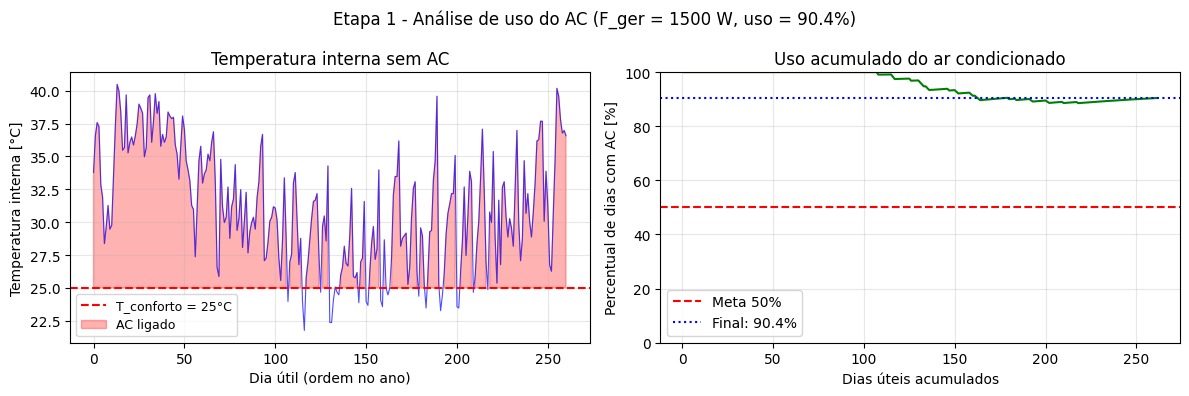

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import math

# Questão 1
df = pd.read_csv('/content/Dados simplificado - Temp. bulbo seco Min, Med, Max diarios.csv')
df['Data'] = pd.to_datetime(df['Dia'])
data_base = pd.Timestamp('2025-01-01')
df['Dia_ano'] = (df['Data'] - data_base).dt.days

T_externa_dados = df['Tmax'].values
dias = df['Dia_ano'].values

print("\n[Dados carregados]")
print(f"  Total de dias: {len(df)}")
print(f"  T_max: média = {df['Tmax'].mean():.1f}°C, max = {df['Tmax'].max():.1f}°C, min = {df['Tmax'].min():.1f}°C")

heff_Atot = 800.0
# Sala comercial média 100 m², heff 8 W/(m²·K), 100*8 = 800
# Potência gerada no ambiente (pessoas + equipamentos)
# Cada pessoa: ~150 W, cada computador: 250 W
F_ger = 1000 + 500
#10 pessoas × 100W = 1000W + 50W / pessoa, notebook medio gera 50W, pessoa media
#gera 100W
f_ac = 23000.0 #100²(area da sala) x 800btu(quantidade recomendada por metro de
#ambiente com incidencia solar) = 80000 btu ~= 23000 W
n = 1.5 #sugestao dada em aula
T_conforto = 25
C = 0.76 # valor kWh em Niteroi

potencia_eletrica = f_ac * n

print("\nParâmetros: ")
print(f"  heff*Atot = {heff_Atot} W/K")
print(f"  F_ger = {F_ger} W")
print(f"  Potência elétrica consumida = {potencia_eletrica:.0f} W")
print(f"  T_conforto = {T_conforto} °C")

def eh_dia_util(dia_ano):
    """
    dia_ano % 7:
    0=seg, 1=ter, 2=qua, 3=qui, 4=sex → True
    5=sab, 6=dom → False
    """
    dia_semana = dia_ano % 7
    return dia_semana < 5

def temperatura_interna_sem_ac(F_ger, heff_Atot, T_ext):
    return F_ger / heff_Atot + T_ext

dias_trabalhados = 0
dias_com_ac = 0
uso_ac_por_dia = []
temperaturas_internas = []

for i, dia in enumerate(dias):
    if not eh_dia_util(dia):
        continue

    dias_trabalhados += 1
    T_ext = T_externa_dados[i]
    T_int = temperatura_interna_sem_ac(F_ger, heff_Atot, T_ext)
    temperaturas_internas.append(T_int)

    if T_int > T_conforto:
        dias_com_ac += 1
        uso_ac_por_dia.append(1)
    else:
        uso_ac_por_dia.append(0)

percentual = (dias_com_ac / dias_trabalhados) * 100

print("\n" + "="*60)
print("RESULTADOS DA SIMULAÇÃO")
print("="*60)
print(f"  Dias trabalhados (seg-sex): {dias_trabalhados}")
print(f"  Dias que precisam de AC: {dias_com_ac}")
print(f"  Percentual de uso: {percentual:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Etapa 1 - Análise de uso do AC (F_ger = {F_ger} W, uso = {percentual:.1f}%)', fontsize=12)

dias_uteis = [i for i, d in enumerate(dias) if eh_dia_util(d)]
axes[0].plot(range(len(temperaturas_internas)), temperaturas_internas, 'b-', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=T_conforto, color='r', linestyle='--', label=f'T_conforto = {T_conforto}°C')
axes[0].fill_between(range(len(temperaturas_internas)), T_conforto,
                      [max(t, T_conforto) for t in temperaturas_internas],
                      where=[t > T_conforto for t in temperaturas_internas],
                      color='red', alpha=0.3, label='AC ligado')
axes[0].set_xlabel('Dia útil (ordem no ano)')
axes[0].set_ylabel('Temperatura interna [°C]')
axes[0].set_title('Temperatura interna sem AC')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

percentual_acum = np.cumsum(uso_ac_por_dia) / np.arange(1, len(uso_ac_por_dia)+1) * 100
axes[1].plot(range(1, len(uso_ac_por_dia)+1), percentual_acum, 'g-', linewidth=1.5)
axes[1].axhline(y=50, color='r', linestyle='--', linewidth=1.5, label='Meta 50%')
axes[1].axhline(y=percentual, color='blue', linestyle=':', label=f'Final: {percentual:.1f}%')
axes[1].set_xlabel('Dias úteis acumulados')
axes[1].set_ylabel('Percentual de dias com AC [%]')
axes[1].set_title('Uso acumulado do ar condicionado')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.savefig('etapa1_resultado.png', dpi=150)
plt.show()


RESULTADOS DO AJUSTE (Tmax)
Coeficiente φ 0 (Média): 29.3959
Coeficiente φ 1 (Cosseno): 3.6858
Coeficiente φ 2 (Seno): 1.9427

 RESULTADOS DO AJUSTE (Tmin)
Coeficiente θ 0 (Média): 21.3268
Coeficiente θ 1 (Cosseno): 3.4624
Coeficiente θ 2 (Seno): 1.8337
Erro Quadrático Médio Tmax (MSE): 11.6520
Erro Quadrático Médio Tmin (MSE): 3.4542


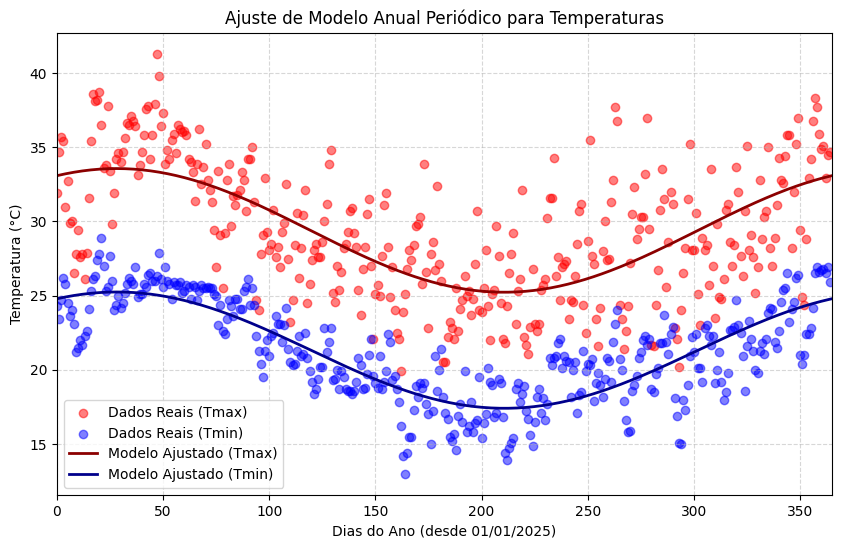

In [ ]:
#Questão 2
N = len(dias)
w = (2 * np.pi) / 365.0

A = np.ones((N, 3), dtype=np.float64)
A[:, 1] = np.cos(w * dias)
A[:, 2] = np.sin(w * dias)

X = A.T @ A
b = A.T @ T_externa_dados
coeficientes_tmax = np.linalg.solve(X, b)

phi_0 = coeficientes_tmax[0]
phi_1 = coeficientes_tmax[1]
phi_2 = coeficientes_tmax[2]

print("RESULTADOS DO AJUSTE (Tmax)")
print(f"Coeficiente φ 0 (Média): {phi_0:.4f}")
print(f"Coeficiente φ 1 (Cosseno): {phi_1:.4f}")
print(f"Coeficiente φ 2 (Seno): {phi_2:.4f}")

T_min_dados = df['Tmin'].values
b_min = A.T @ T_min_dados
coeficientes_tmin = np.linalg.solve(X, b_min)

theta_0 = coeficientes_tmin[0]
theta_1 = coeficientes_tmin[1]
theta_2 = coeficientes_tmin[2]

print("\n RESULTADOS DO AJUSTE (Tmin)")
print(f"Coeficiente θ 0 (Média): {theta_0:.4f}")
print(f"Coeficiente θ 1 (Cosseno): {theta_1:.4f}")
print(f"Coeficiente θ 2 (Seno): {theta_2:.4f}")

T_max_pred = phi_0 + phi_1 * np.cos(w * dias) + phi_2 * np.sin(w * dias)
mse_max = np.mean((T_externa_dados - T_max_pred)**2)
T_min_pred = theta_0 + theta_1 * np.cos(w * dias) + theta_2 * np.sin(w * dias)
mse_min = np.mean((T_min_dados - T_min_pred)**2)

print(f"Erro Quadrático Médio Tmax (MSE): {mse_max:.4f}")
print(f"Erro Quadrático Médio Tmin (MSE): {mse_min:.4f}")

d_plot = np.linspace(0, 365, num=365)
T_max_plot = phi_0 + phi_1 * np.cos(w * d_plot) + phi_2 * np.sin(w * d_plot)
T_min_plot = theta_0 + theta_1 * np.cos(w * d_plot) + theta_2 * np.sin(w * d_plot)

plt.figure(figsize=(10, 6))
plt.scatter(dias, T_externa_dados, alpha=0.5, color='red', label='Dados Reais (Tmax)')
plt.scatter(dias, T_min_dados, alpha=0.5, color='blue', label='Dados Reais (Tmin)')
plt.plot(d_plot, T_max_plot, color='darkred', linewidth=2, label='Modelo Ajustado (Tmax)')
plt.plot(d_plot, T_min_plot, color='darkblue', linewidth=2, label='Modelo Ajustado (Tmin)')
plt.title('Ajuste de Modelo Anual Periódico para Temperaturas')
plt.xlabel('Dias do Ano (desde 01/01/2025)')
plt.ylabel('Temperatura (°C)')
plt.xlim(0, 365)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

  Horários: 24 pontos (00:30 às 23:30)
  T_verão: min=19.0°C, max=27.8°C
  T_inverno: min=13.2°C, max=25.9°C


NORMALIZAÇÃO DOS DADOS

Verão:
  T_min = 19.0°C, T_max = 27.8°C
  Amplitude = 8.8°C

Inverno:
  T_min = 13.2°C, T_max = 25.9°C
  Amplitude = 12.7°C


AJUSTE DAS SPLINES CÚBICAS PERIÓDICAS
  Condição de contorno: periódica (bc_type='periodic')
  Continuidade: C² (função, primeira e segunda derivadas contínuas)


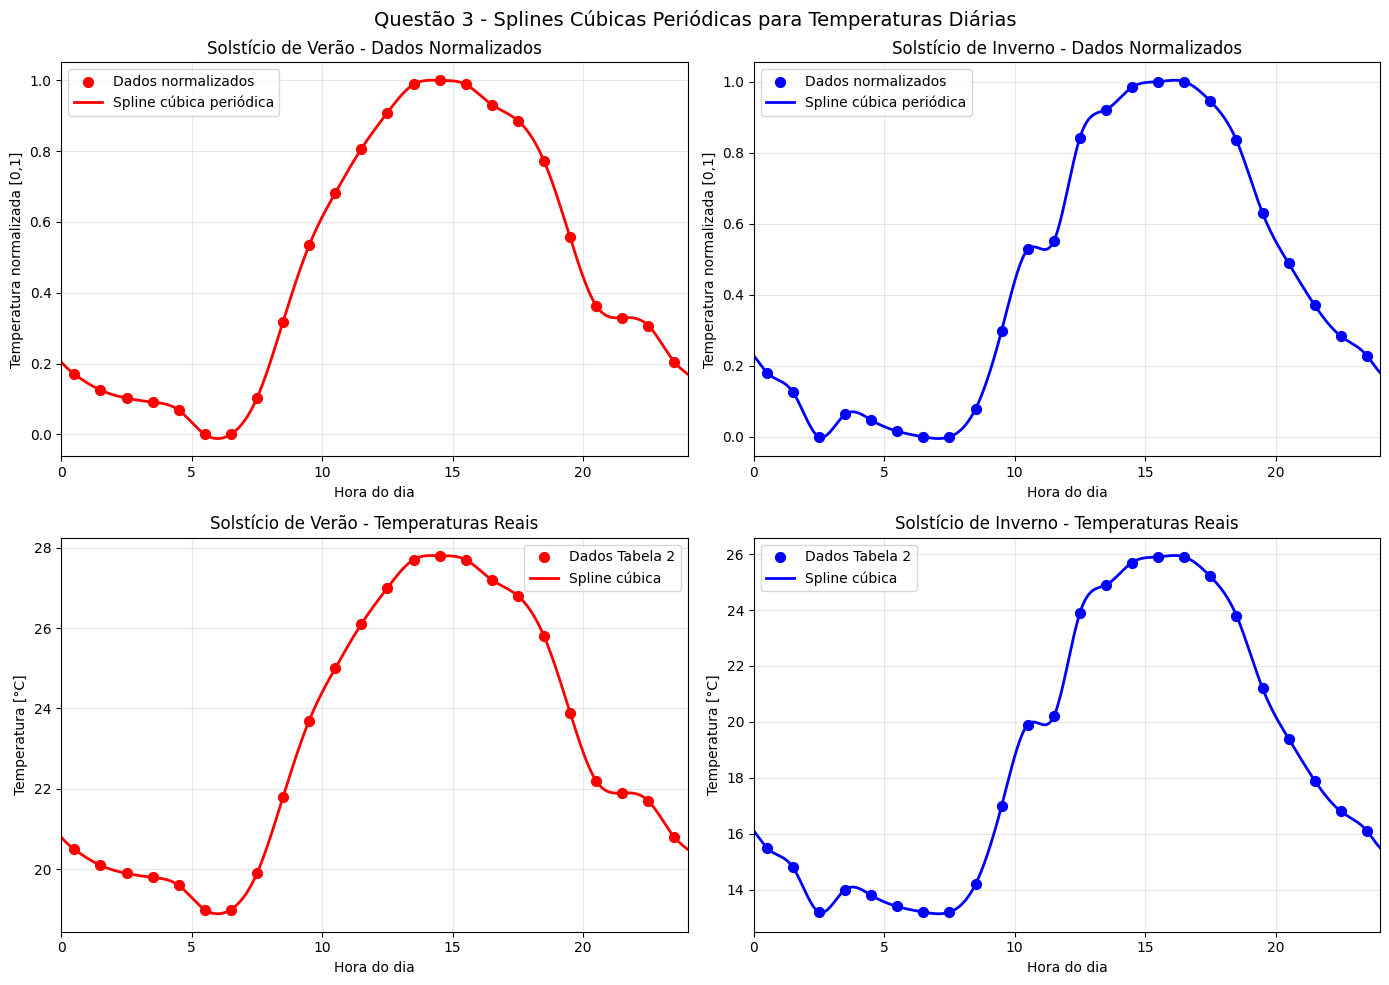

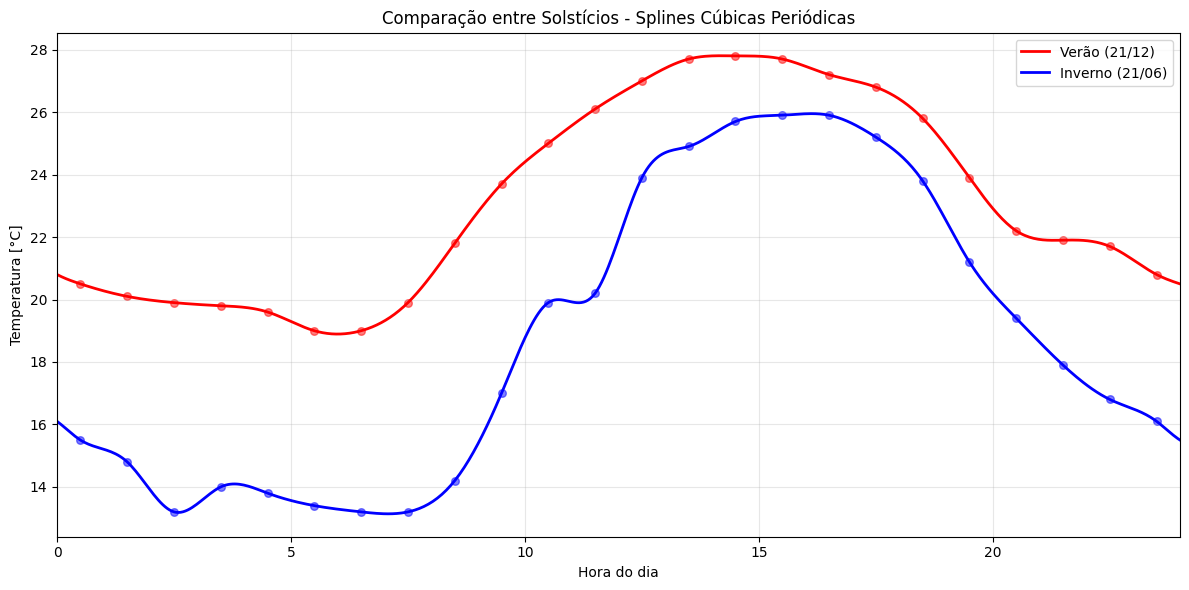

VALIDAÇÃO DA CONDIÇÃO PERIÓDICA
Verão: S(0) = 0.204545, S(24) = 0.170455 → diferença = 3.41e-02
Inverno: S(0) = 0.228346, S(24) = 0.181102 → diferença = 4.72e-02


In [ ]:
# Questao 3
# Horários em horas (convertendo HH:MM para horas decimais), horarios da tabela 2 do pdf
horarios = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5,
                     12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5])

# Temperaturas - Verão (dados da Tabela 2 do pdf)
T_verao = np.array([20.5, 20.1, 19.9, 19.8, 19.6, 19.0, 19.0, 19.9, 21.8, 23.7, 25.0, 26.1,
                    27.0, 27.7, 27.8, 27.7, 27.2, 26.8, 25.8, 23.9, 22.2, 21.9, 21.7, 20.8])

# Temperaturas - Inverno (dados da Tabela 2 do pdf)
T_inverno = np.array([15.5, 14.8, 13.2, 14.0, 13.8, 13.4, 13.2, 13.2, 14.2, 17.0, 19.9, 20.2,
                      23.9, 24.9, 25.7, 25.9, 25.9, 25.2, 23.8, 21.2, 19.4, 17.9, 16.8, 16.1])

print(f"  Horários: {len(horarios)} pontos (00:30 às 23:30)")
print(f"  T_verão: min={np.min(T_verao):.1f}°C, max={np.max(T_verao):.1f}°C")
print(f"  T_inverno: min={np.min(T_inverno):.1f}°C, max={np.max(T_inverno):.1f}°C")

print("\n")
print("NORMALIZAÇÃO DOS DADOS")

def normalizar(T, T_min, T_max):
    """Normaliza temperatura para [0,1]"""
    return (T - T_min) / (T_max - T_min)

def desnormalizar(T_norm, T_min, T_max):
    """Desnormaliza de [0,1] para temperatura original"""
    return T_norm * (T_max - T_min) + T_min

# Verão
T_verao_min = np.min(T_verao)
T_verao_max = np.max(T_verao)
T_verao_norm = normalizar(T_verao, T_verao_min, T_verao_max)

# Inverno
T_inverno_min = np.min(T_inverno)
T_inverno_max = np.max(T_inverno)
T_inverno_norm = normalizar(T_inverno, T_inverno_min, T_inverno_max)

print(f"\nVerão:")
print(f"  T_min = {T_verao_min:.1f}°C, T_max = {T_verao_max:.1f}°C")
print(f"  Amplitude = {T_verao_max - T_verao_min:.1f}°C")

print(f"\nInverno:")
print(f"  T_min = {T_inverno_min:.1f}°C, T_max = {T_inverno_max:.1f}°C")
print(f"  Amplitude = {T_inverno_max - T_inverno_min:.1f}°C")

print("\n")
print("AJUSTE DAS SPLINES CÚBICAS PERIÓDICAS")

horarios_periodico = np.append(horarios, 24.0)
T_verao_norm_periodico = np.append(T_verao_norm, T_verao_norm[0])
T_inverno_norm_periodico = np.append(T_inverno_norm, T_inverno_norm[0])

# Criar splines com condição periódica
spline_verao = CubicSpline(horarios_periodico, T_verao_norm_periodico, bc_type='periodic')
spline_inverno = CubicSpline(horarios_periodico, T_inverno_norm_periodico, bc_type='periodic')

print("  Condição de contorno: periódica (bc_type='periodic')")
print("  Continuidade: C² (função, primeira e segunda derivadas contínuas)")

# Criar grid fino para plotar curvas suaves
horas_fino = np.linspace(0, 24, 500)
T_verao_norm_fino = spline_verao(horas_fino)
T_inverno_norm_fino = spline_inverno(horas_fino)

# Desnormalizar para obter temperaturas reais
T_verao_fino = desnormalizar(T_verao_norm_fino, T_verao_min, T_verao_max)
T_inverno_fino = desnormalizar(T_inverno_norm_fino, T_inverno_min, T_inverno_max)

# Graficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Questão 3 - Splines Cúbicas Periódicas para Temperaturas Diárias', fontsize=14)
# Gráfico 1: Verão (normalizado)
ax1 = axes[0, 0]
ax1.scatter(horarios, T_verao_norm, color='red', s=50, zorder=5, label='Dados normalizados')
ax1.plot(horas_fino, T_verao_norm_fino, 'r-', linewidth=2, label='Spline cúbica periódica')
ax1.set_xlabel('Hora do dia')
ax1.set_ylabel('Temperatura normalizada [0,1]')
ax1.set_title(f'Solstício de Verão - Dados Normalizados')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 24)
# Gráfico 2: Inverno (normalizado)
ax2 = axes[0, 1]
ax2.scatter(horarios, T_inverno_norm, color='blue', s=50, zorder=5, label='Dados normalizados')
ax2.plot(horas_fino, T_inverno_norm_fino, 'b-', linewidth=2, label='Spline cúbica periódica')
ax2.set_xlabel('Hora do dia')
ax2.set_ylabel('Temperatura normalizada [0,1]')
ax2.set_title(f'Solstício de Inverno - Dados Normalizados')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 24)

# Gráfico 3: Verão (temperatura real)
ax3 = axes[1, 0]
ax3.scatter(horarios, T_verao, color='red', s=50, zorder=5, label='Dados Tabela 2')
ax3.plot(horas_fino, T_verao_fino, 'r-', linewidth=2, label='Spline cúbica')
ax3.set_xlabel('Hora do dia')
ax3.set_ylabel('Temperatura [°C]')
ax3.set_title(f'Solstício de Verão - Temperaturas Reais')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 24)

# Gráfico 4: Inverno (temperatura real)
ax4 = axes[1, 1]
ax4.scatter(horarios, T_inverno, color='blue', s=50, zorder=5, label='Dados Tabela 2')
ax4.plot(horas_fino, T_inverno_fino, 'b-', linewidth=2, label='Spline cúbica')
ax4.set_xlabel('Hora do dia')
ax4.set_ylabel('Temperatura [°C]')
ax4.set_title(f'Solstício de Inverno - Temperaturas Reais')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 24)
plt.tight_layout()
plt.savefig('etapa3_splines.png', dpi=150)
plt.show()

# 7. Comparaçao entre o verão e o inverno
fig2, ax = plt.subplots(figsize=(12, 6))
ax.plot(horas_fino, T_verao_fino, 'r-', linewidth=2, label='Verão (21/12)')
ax.plot(horas_fino, T_inverno_fino, 'b-', linewidth=2, label='Inverno (21/06)')
ax.scatter(horarios, T_verao, color='red', s=30, alpha=0.5)
ax.scatter(horarios, T_inverno, color='blue', s=30, alpha=0.5)
ax.set_xlabel('Hora do dia')
ax.set_ylabel('Temperatura [°C]')
ax.set_title('Comparação entre Solstícios - Splines Cúbicas Periódicas')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 24)
plt.tight_layout()
plt.savefig('etapa3_comparacao_solsticios.png', dpi=150)
plt.show()

# 9. validaçao da peridiocidade
print("VALIDAÇÃO DA CONDIÇÃO PERIÓDICA")

# Verificar se S(0) ≈ S(24)
T_verao_norm_0 = spline_verao(0)
T_verao_norm_24 = spline_verao(24)
T_inverno_norm_0 = spline_inverno(0)
T_inverno_norm_24 = spline_inverno(24)

print(f"Verão: S(0) = {T_verao_norm_0:.6f}, S(24) = {T_verao_norm_24:.6f} → diferença = {abs(T_verao_norm_0 - T_verao_norm_24):.2e}")
print(f"Inverno: S(0) = {T_inverno_norm_0:.6f}, S(24) = {T_inverno_norm_24:.6f} → diferença = {abs(T_inverno_norm_0 - T_inverno_norm_24):.2e}")

# 10. Salvar funçoes para proxima etapa
def T_verao_spline_normalizada(h):
    """Retorna temperatura normalizada [0,1] para verão em dado horário h [0,24]"""
    return spline_verao(h % 24)  # % 24 garante periodicidade

def T_inverno_spline_normalizada(h):
    """Retorna temperatura normalizada [0,1] para inverno em dado horário h [0,24]"""
    return spline_inverno(h % 24)


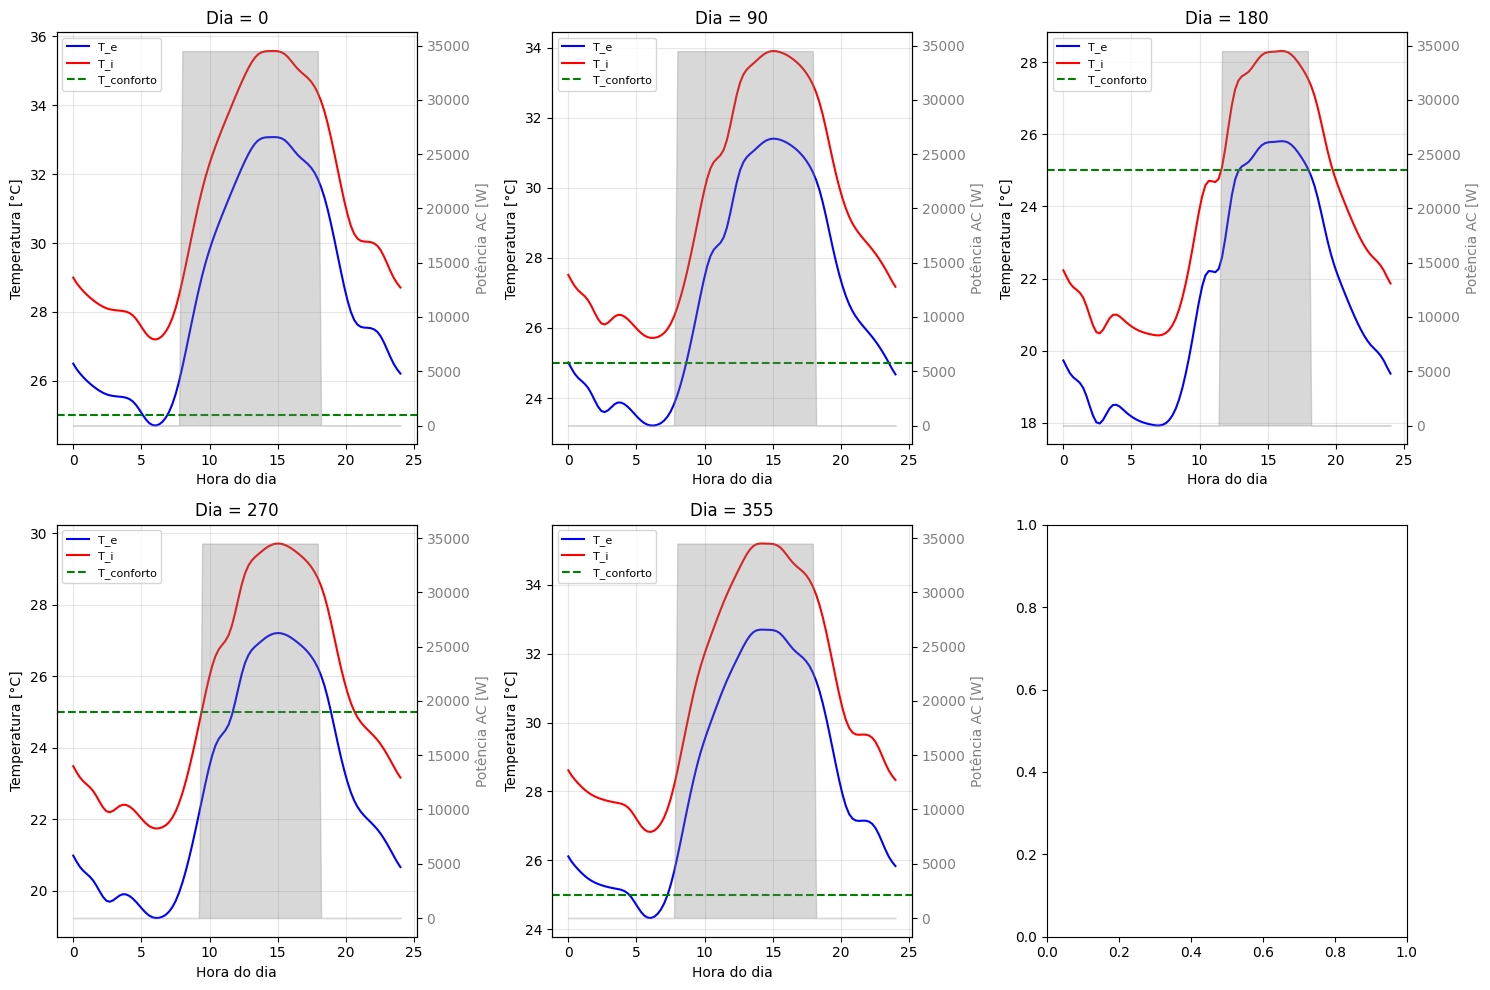

In [ ]:
#questao 4

df['Data'] = pd.to_datetime(df['Dia'])
data_base = pd.Timestamp('2025-01-01')
df['Dia_ano'] = (df['Data'] - data_base).dt.days

dias = df['Dia_ano'].values
T_min_dados = df['Tmin'].values
T_max_dados = df['Tmax'].values

omega = 2 * np.pi / 365
N = len(dias)
A = np.ones((N, 3), dtype=np.float64)
A[:, 1] = np.cos(omega * dias)
A[:, 2] = np.sin(omega * dias)

X = A.T @ A
b_min = A.T @ T_min_dados
thetas = np.linalg.solve(X, b_min)
b_max = A.T @ T_max_dados
phis = np.linalg.solve(X, b_max)

def T_min_modelo(d):
    return thetas[0] + thetas[1] * np.cos(omega * d) + thetas[2] * np.sin(omega * d)

def T_max_modelo(d):
    return phis[0] + phis[1] * np.cos(omega * d) + phis[2] * np.sin(omega * d)

horarios = np.array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5,
                     12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5, 20.5, 21.5, 22.5, 23.5])

T_verao = np.array([20.5, 20.1, 19.9, 19.8, 19.6, 19.0, 19.0, 19.9, 21.8, 23.7, 25.0, 26.1,
                    27.0, 27.7, 27.8, 27.7, 27.2, 26.8, 25.8, 23.9, 22.2, 21.9, 21.7, 20.8])

T_inverno = np.array([15.5, 14.8, 13.2, 14.0, 13.8, 13.4, 13.2, 13.2, 14.2, 17.0, 19.9, 20.2,
                      23.9, 24.9, 25.7, 25.9, 25.9, 25.2, 23.8, 21.2, 19.4, 17.9, 16.8, 16.1])

T_verao_min = np.min(T_verao)
T_verao_max = np.max(T_verao)
T_inverno_min = np.min(T_inverno)
T_inverno_max = np.max(T_inverno)

T_verao_norm = (T_verao - T_verao_min) / (T_verao_max - T_verao_min)
T_inverno_norm = (T_inverno - T_inverno_min) / (T_inverno_max - T_inverno_min)

horarios_periodico = np.append(horarios, 24.0)
T_verao_norm_periodico = np.append(T_verao_norm, T_verao_norm[0])
T_inverno_norm_periodico = np.append(T_inverno_norm, T_inverno_norm[0])

spline_verao = CubicSpline(horarios_periodico, T_verao_norm_periodico, bc_type='periodic')
spline_inverno = CubicSpline(horarios_periodico, T_inverno_norm_periodico, bc_type='periodic')
#Função alpha(d) com interpolação linear
def alpha(d):
    if 0 <= d <= 171:
        return (19/3420) * d + 1/20
    elif 171 < d <= 355:
        return (-1/184) * d + 355/184
    else:
        return (1/200) * d - 355/200

heff_Atot = 800.0
F_ger = 2000.0
f_ac = 23000.0
eta = 1.5
T_conforto = 25.0
C = 0.76
potencia_eletrica = f_ac * eta

#Modelo T_e(d, h) conforme a fórmula
def T_externa(d, h):
    Tmin_dia = T_min_modelo(d)
    Tmax_dia = T_max_modelo(d)
    a = alpha(d)
    T_norm = (1 - a) * spline_verao(h) + a * spline_inverno(h)
    return T_norm * (Tmax_dia - Tmin_dia) + Tmin_dia

def eh_dia_util(d):
    return (d % 7) < 5

def T_interna_sem_ac(d, h):
    return F_ger / heff_Atot + T_externa(d, h)

dias_teste = [0, 90, 180, 270, 355]
horas_teste = np.linspace(0, 24, 100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, d in enumerate(dias_teste):
    row = idx // 3
    col = idx % 3
    Te = [T_externa(d, h) for h in horas_teste]
    Ti = [F_ger/heff_Atot + te for te in Te]
    #Determinar quando o AC deve ser ligado e potência p(d, h)
    p = [potencia_eletrica if ti > T_conforto and 8 <= h <= 18 else 0 for ti, h in zip(Ti, horas_teste)]

    ax = axes[row, col]
    #Gráfico com T_e, T_i e p
    ax.plot(horas_teste, Te, 'b-', label='T_e', linewidth=1.5)
    ax.plot(horas_teste, Ti, 'r-', label='T_i', linewidth=1.5)
    ax.axhline(y=T_conforto, color='g', linestyle='--', label='T_conforto')
    ax.set_xlabel('Hora do dia')
    ax.set_ylabel('Temperatura [°C]')
    ax.set_title(f'Dia = {d}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.fill_between(horas_teste, 0, p, alpha=0.3, color='gray', label='Potência')
    ax2.set_ylabel('Potência AC [W]', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.savefig('etapa4_Te_Ti_p.png', dpi=150)
plt.show()

In [ ]:
# Questão 5

def quadratura_retangulo_2d(f, ax, bx, ay, by, nx, ny):
    dx = (bx - ax) / nx
    dy = (by - ay) / ny
    soma_volumes = 0.0

    for i in range(nx):
        x_m = ax + (i + 0.5) * dx
        for j in range(ny):
            y_m = ay + (j + 0.5) * dy

            soma_volumes += f(x_m, y_m)

    area_base = dx * dy
    return (soma_volumes * area_base)

def equacao_pot(d, h):
    if h < 8 or h >= 18:
        return 0.0

    dia_inteiro = math.floor(d)
    if dia_inteiro % 7 >= 5:
        return 0.0

    return potencia_eletrica

lim_inf_d = 0.0
lim_sup_d = 365.0
lim_inf_h = 0.0
lim_sup_h = 24.0

nx = 365
ny = 48


energia_total_wh = quadratura_retangulo_2d(equacao_pot, lim_inf_d, lim_sup_d, lim_inf_h, lim_sup_h, nx, ny)
energia_total_kwh = energia_total_wh / 1000
print(f"Malha {nx}x{ny}: {energia_total_kwh:.2f} kW")

custo_total = energia_total_kwh * C

print(f"Custo total de ar condicionado no ano: R${custo_total:.2f}")

Malha 365x48: 90045.00 kW
Custo total de ar condicionado no ano: R$68434.20


Par ideal encontrado: Nd=3079, Nh=3079
Energia calculada: 90038.98 kWh
Custo total: R$ 68429.62


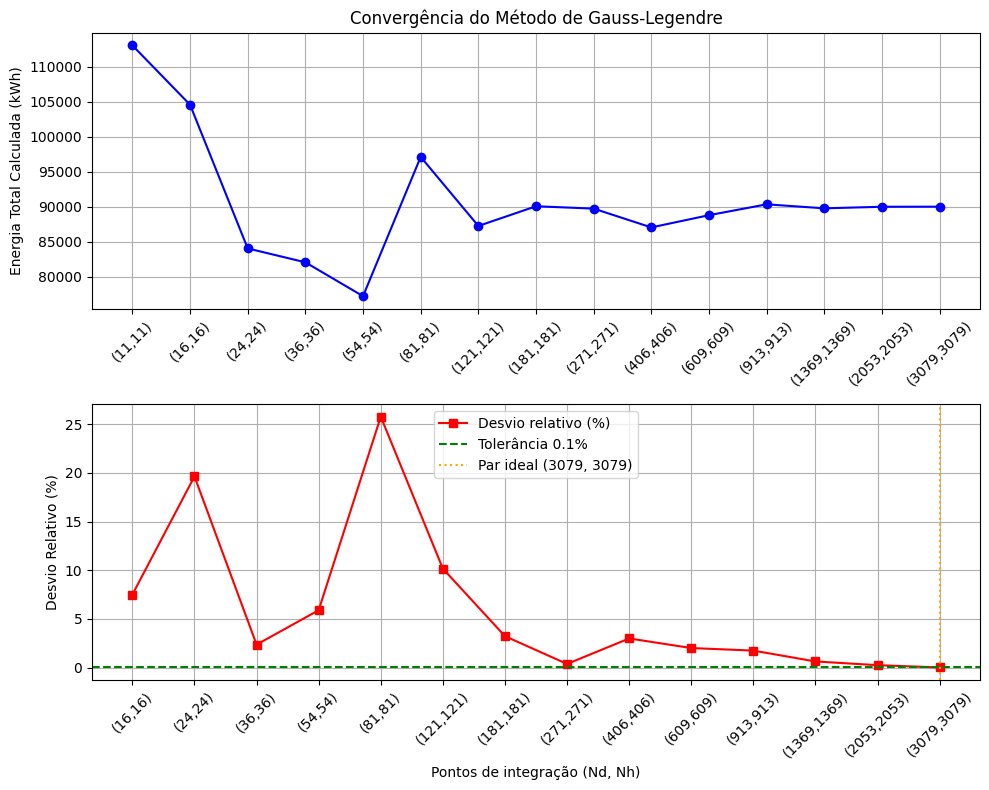

In [ ]:
# Questão 6

def calcular_gauss_legendre(Nd, Nh):
    tvec_d, wvec_d = np.polynomial.legendre.leggauss(Nd)
    tvec_h, wvec_h = np.polynomial.legendre.leggauss(Nh)

    dvec = (lim_sup_d + lim_inf_d)/2 + ((lim_sup_d - lim_inf_d)/2) * tvec_d
    wvec_d_mapped = wvec_d * ((lim_sup_d - lim_inf_d)/2)

    hvec = (lim_sup_h + lim_inf_h)/2 + ((lim_sup_h - lim_inf_h)/2) * tvec_h
    wvec_h_mapped = wvec_h * ((lim_sup_h - lim_inf_h)/2)

    Y_matrix = np.zeros((Nd, Nh))
    for i in range(Nd):
        for j in range(Nh):
            Y_matrix[i, j] = equacao_pot(dvec[i], hvec[j])

    energia_wh = np.dot(wvec_d_mapped, np.dot(Y_matrix, wvec_h_mapped))
    return energia_wh/1000

resultados_energia = []
desvios_relativos = []
par_ideal = None
Nvec_pares = []

Nd, Nh = 11, 11
energia_anterior = None

while par_ideal is None:
    energia = calcular_gauss_legendre(Nd, Nh)
    resultados_energia.append(energia)
    Nvec_pares.append((Nd, Nh))

    if energia_anterior is not None:
        desvio = abs(energia - energia_anterior) / abs(energia_anterior) * 100
        desvios_relativos.append(desvio)

        if desvio < 0.1:
            par_ideal = (Nd, Nh)
    else:
        desvios_relativos.append(None)

    energia_anterior = energia
    Nd = int(Nd * 1.5)
    Nh = int(Nh * 1.5)

print(f"Par ideal encontrado: Nd={par_ideal[0]}, Nh={par_ideal[1]}")
print(f"Energia calculada: {resultados_energia[-1]:.2f} kWh")
print(f"Custo total: R$ {resultados_energia[-1] * C:.2f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

N_labels = [f"({Nd},{Nh})" for Nd, Nh in Nvec_pares]

ax1.plot(range(len(Nvec_pares)), resultados_energia, marker='o', linestyle='-', color='b')
ax1.set_title('Convergência do Método de Gauss-Legendre')
ax1.set_ylabel('Energia Total Calculada (kWh)')
ax1.set_xticks(range(len(Nvec_pares)))
ax1.set_xticklabels(N_labels, rotation=45)
ax1.grid(True)

desvios_plot = [d for d in desvios_relativos if d is not None]
ax2.plot(range(1, len(Nvec_pares)), desvios_plot, marker='s', linestyle='-', color='r', label='Desvio relativo (%)')
ax2.axhline(y=0.1, color='g', linestyle='--', label='Tolerância 0.1%')
if par_ideal:
    idx_ideal = Nvec_pares.index(par_ideal)
    ax2.axvline(x=idx_ideal, color='orange', linestyle=':', label=f'Par ideal {par_ideal}')
ax2.set_ylabel('Desvio Relativo (%)')
ax2.set_xlabel('Pontos de integração (Nd, Nh)')
ax2.set_xticks(range(1, len(Nvec_pares)))
ax2.set_xticklabels(N_labels[1:], rotation=45)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()